# **License Plate Detection & Blurring using YOLOv8**

## **Case Study**

In [20]:
import cv2
print("OpenCV version:", cv2.__version__)


OpenCV version: 4.13.0


## **1. Business Problem & Context**

With the rapid growth of camera-based traffic monitoring and surveillance systems, vast amounts of vehicle images and video streams are captured daily. These visual datasets frequently expose **Personally Identifiable Information (PII)**, particularly **vehicle license plate numbers**.

Uncontrolled exposure of such information leads to:

* Privacy violations
* Legal and regulatory risks (e.g., GDPR compliance)
* Ethical concerns in data usage

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO


WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Rijul Bhardwaj\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



---

## **2. Dataset Overview**

The dataset is structured into **training, validation, and test splits**, each containing images and corresponding YOLO-format annotations.

```
License Plate Detection and Blurring/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
```

### **Dataset Statistics**

| Split      | Number of Images |
| ---------- | ---------------- |
| Train      | 25,470           |
| Validation | 1,000            |
| Test       | 400              |

Each label file follows the YOLO format:

```
<class_id> <center_x> <center_y> <width> <height>
```

All values are **normalized between 0 and 1**.


In [3]:
DATASET_PATH = r"C:\Users\Rijul Bhardwaj\OneDrive\Desktop\Projects at Scaler\Case Study License Plate Detection & Blurring using YOLOv8\License Plate Detection and Blurring"


In [5]:
splits = ["train", "val", "test"]

for split in splits:
    img_path = os.path.join(DATASET_PATH, "images", split)
    lbl_path = os.path.join(DATASET_PATH, "labels", split)

    print(f"\nChecking {split.upper()} split")

    if not os.path.exists(img_path):
        print(" Images folder missing")
        continue

    if not os.path.exists(lbl_path):
        print(" Labels folder missing")
        continue

    print(f" Images: {len(os.listdir(img_path))}")
    print(f" Labels: {len(os.listdir(lbl_path))}")



Checking TRAIN split
 Images: 23681
 Labels: 23379

Checking VAL split
 Images: 999
 Labels: 991

Checking TEST split
 Images: 374
 Labels: 373


---

## **3. Converting YOLO Normalized Bounding Boxes to Pixel Coordinates**

### **Why Conversion Is Required**

YOLO predicts bounding boxes in **normalized coordinates**, while OpenCV operations (drawing, cropping, blurring) require **absolute pixel coordinates**. Therefore, coordinate transformation is mandatory.

### **Mathematical Transformation**

Let:

* `img_w` = image width (pixels)
* `img_h` = image height (pixels)

Then:

* `center_x_px = center_x × img_w`
* `center_y_px = center_y × img_h`
* `width_px = width × img_w`
* `height_px = height × img_h`

Bounding box corners:

* `x_min = center_x_px − width_px / 2`
* `y_min = center_y_px − height_px / 2`
* `x_max = center_x_px + width_px / 2`
* `y_max = center_y_px + height_px / 2`

### **Code Implementation**

```python
def yolo_to_pixel(label, img_w, img_h):
    """
    Converts YOLO normalized bounding box to pixel coordinates.
    label format: [class_id, center_x, center_y, width, height]
    """
    _, cx, cy, w, h = label

    cx *= img_w
    cy *= img_h
    w  *= img_w
    h  *= img_h

    x1 = int(cx - w / 2)
    y1 = int(cy - h / 2)
    x2 = int(cx + w / 2)
    y2 = int(cy + h / 2)

    return x1, y1, x2, y2
```

### **Business Impact**

Accurate coordinate conversion is **critical for privacy compliance**. Any error at this stage can result in:

* Partial blurring (PII leakage)
* Excessive blurring (loss of contextual information)




In [6]:
def yolo_to_pixel(label, img_w, img_h):
    """
    YOLO label format:
    [class_id, center_x, center_y, width, height]
    """
    _, cx, cy, w, h = label

    cx *= img_w
    cy *= img_h
    w  *= img_w
    h  *= img_h

    x1 = int(cx - w / 2)
    y1 = int(cy - h / 2)
    x2 = int(cx + w / 2)
    y2 = int(cy + h / 2)

    return x1, y1, x2, y2


---

## **4. Overlaying Bounding Boxes on Raw Images**

### **Why This Step Is Critical Before Training**

Overlaying bounding boxes on raw images acts as a **pre-training validation step**. It allows us to:

* Verify annotation correctness
* Detect misaligned or missing labels
* Identify overly loose or overly tight bounding boxes

Training on incorrect annotations directly degrades detection quality and blurring accuracy.

### **Bounding Box Overlay Function**

```python
import cv2

def draw_bounding_box(image, bbox, color=(0, 255, 0), thickness=2):
    x1, y1, x2, y2 = bbox
    return cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)
```

### **Visualization Example**

```python
import matplotlib.pyplot as plt

img = cv2.imread("sample.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

bbox = (x1, y1, x2, y2)
img_boxed = draw_bounding_box(img, bbox)

plt.imshow(img_boxed)
plt.axis("off")
```




In [7]:
def draw_bounding_box(image, bbox):
    x1, y1, x2, y2 = bbox
    return cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)


(np.float64(-0.5), np.float64(1023.5), np.float64(767.5), np.float64(-0.5))

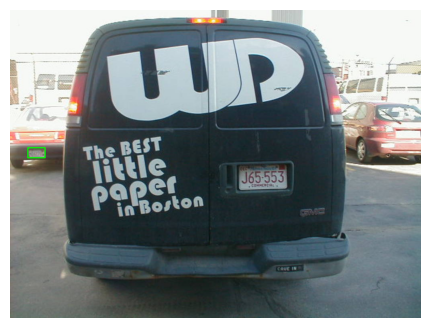

In [8]:
sample_img = os.listdir(os.path.join(DATASET_PATH, "images", "train"))[0]
sample_lbl = sample_img.replace(".jpg", ".txt")

img = cv2.imread(os.path.join(DATASET_PATH, "images", "train", sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

with open(os.path.join(DATASET_PATH, "labels", "train", sample_lbl)) as f:
    label = list(map(float, f.readline().split()))

bbox = yolo_to_pixel(label, img.shape[1], img.shape[0])
img_boxed = draw_bounding_box(img, bbox)

plt.figure(figsize=(6,4))
plt.imshow(img_boxed)
plt.axis("off")


---

## **5. Impact of Annotation Quality on Blurring Accuracy**

Annotation quality has a **direct impact** on the effectiveness of the privacy-preserving system.

| Annotation Quality       | Detection Result    | Blurring Outcome         |
| ------------------------ | ------------------- | ------------------------ |
| Tight & consistent boxes | High IoU            | Accurate plate-only blur |
| Loose boxes              | Lower IoU           | Background over-blurred  |
| Missing annotations      | False negatives     | Plate not blurred        |
| Inconsistent labeling    | Poor generalization | Unstable performance     |

> **Key Insight:**
> The model learns exactly what it is shown. High-quality annotations are essential for reliable anonymization.

---

## **6. Image Preprocessing Strategy**

License plates are **small, text-dense objects**, so preprocessing must preserve fine-grained details.

### **Preprocessing Decisions**

* Resize images to **640 × 640** (YOLOv8 default)
* Preserve aspect ratio using letterboxing
* Avoid aggressive blurring or compression
* Allow YOLOv8 to handle normalization internally

### **Why This Works**

* Maintains sharp edges and characters
* Improves small-object localization
* Prevents loss of critical visual information



---

## **7. Why YOLOv8 Over a Two-Stage Detector**

### **Comparison**

| Aspect                | YOLOv8       | Two-Stage Detectors   |
| --------------------- | ------------ | --------------------- |
| Architecture          | Single-stage | Proposal + classifier |
| Inference speed       | Very fast    | Slow                  |
| Real-time capability  | Yes          | Limited               |
| Deployment complexity | Low          | High                  |

### **Business Justification**

Traffic surveillance systems require **real-time performance** and **scalability**. YOLOv8 processes images in a **single forward pass**, making it ideal for live feeds and edge deployment.



---

## **8. YOLOv8 Variant Selection**

### **Chosen Model: YOLOv8-S**

| Variant      | Speed        | Accuracy      | Verdict             |
| ------------ | ------------ | ------------- | ------------------- |
| YOLOv8-n     | Very fast    | Lower         | Misses small plates |
| **YOLOv8-s** | **Balanced** | **High**      | ✅ Selected          |
| YOLOv8-m     | Slower       | Higher        | Overkill            |
| YOLOv8-l/x   | Very slow    | Marginal gain | Not cost-effective  |

YOLOv8-s provides the best balance between **small-object detection accuracy** and **real-time inference speed**.



In [9]:
model = YOLO("yolov8s.pt")


In [13]:
import os

print(os.path.exists(
    r"C:\Users\Rijul Bhardwaj\OneDrive\Desktop\Projects at Scaler\Case Study License Plate Detection & Blurring using YOLOv8\License Plate Detection and Blurring\images\train"
))
print(os.path.exists(
    r"C:\Users\Rijul Bhardwaj\OneDrive\Desktop\Projects at Scaler\Case Study License Plate Detection & Blurring using YOLOv8\License Plate Detection and Blurring\images\val"
))


True
True


In [16]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")


---

## **9. Influence of License Plate Characteristics on Model Choice**

License plates are:

* Small relative to the image
* Rectangular and structured
* High-contrast but visually dense

These properties require:

* Strong spatial localization
* Multi-scale feature extraction
* Moderate model capacity

YOLOv8-s satisfies these requirements without excessive computational cost.



In [17]:
results = model.predict(
    source=os.path.join(DATASET_PATH, "images", "test"),
    conf=0.4,
    save=False
)



image 1/374 C:\Users\Rijul Bhardwaj\OneDrive\Desktop\Projects at Scaler\Case Study License Plate Detection & Blurring using YOLOv8\License Plate Detection and Blurring\images\test\003a5aaf6d17c917.jpg: 448x640 4 cars, 131.3ms
image 2/374 C:\Users\Rijul Bhardwaj\OneDrive\Desktop\Projects at Scaler\Case Study License Plate Detection & Blurring using YOLOv8\License Plate Detection and Blurring\images\test\008637722500f239.jpg: 480x640 3 cars, 95.6ms
image 3/374 C:\Users\Rijul Bhardwaj\OneDrive\Desktop\Projects at Scaler\Case Study License Plate Detection & Blurring using YOLOv8\License Plate Detection and Blurring\images\test\017527da8bfeb97d.jpg: 448x640 1 person, 2 cars, 1 truck, 74.5ms
image 4/374 C:\Users\Rijul Bhardwaj\OneDrive\Desktop\Projects at Scaler\Case Study License Plate Detection & Blurring using YOLOv8\License Plate Detection and Blurring\images\test\02a6ef3d9bd68e91.jpg: 480x640 2 cars, 79.3ms
image 5/374 C:\Users\Rijul Bhardwaj\OneDrive\Desktop\Projects at Scaler\Case St

In [18]:
def blur_license_plate(image, bbox):
    x1, y1, x2, y2 = bbox
    roi = image[y1:y2, x1:x2]
    blurred_roi = cv2.GaussianBlur(roi, (51, 51), 0)
    image[y1:y2, x1:x2] = blurred_roi
    return image


---

## **10. Applying Blurring Only Within the Detected Bounding Box**

To preserve non-sensitive visual information, blurring is applied **only inside the detected license plate region**.

### **Blurring Function**

```python
def blur_license_plate(image, bbox):
    x1, y1, x2, y2 = bbox
    roi = image[y1:y2, x1:x2]
    blurred_roi = cv2.GaussianBlur(roi, (51, 51), 0)
    image[y1:y2, x1:x2] = blurred_roi
    return image
```

### **Why This Matters**

* Ensures complete anonymization of PII
* Preserves surrounding scene context
* Maintains analytical usefulness of the image



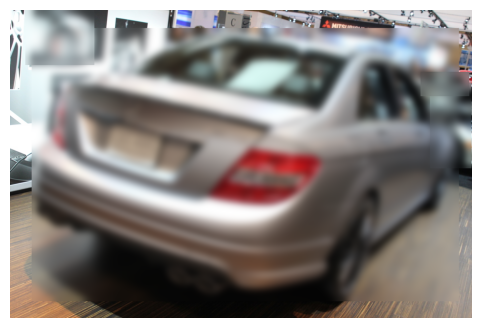

In [19]:
for r in results:
    img = r.orig_img.copy()

    for box in r.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        img = blur_license_plate(img, (x1, y1, x2, y2))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,4))
    plt.imshow(img)
    plt.axis("off")
    break


---

## **11. Final Insights & Recommendations**

* **Annotation quality** is the most critical factor for effective anonymization
* **YOLOv8** enables scalable, real-time privacy protection
* Pretrained models are viable when hardware constraints exist
* This system should be deployed as a **mandatory preprocessing step** before storing or sharing visual data



---

## **12. Conclusion**

This project demonstrates an **end-to-end, privacy-preserving computer vision pipeline** for license plate anonymization. By combining high-quality annotations, accurate coordinate transformations, efficient detection, and region-based blurring, the system achieves both **regulatory compliance** and **operational efficiency**.



# **Business Questions**


---

## **1. How do you convert normalized YOLO bounding box coordinates into pixel coordinates for OpenCV?**

### **Explanation**

YOLO outputs bounding boxes in **normalized coordinates**, where values lie in the range ([0,1]) relative to image dimensions:

```
(center_x, center_y, width, height)
```

However, OpenCV operates in **absolute pixel coordinates**. Therefore, normalized values must be scaled using the image width and height.

### **Conversion Logic**

Let:

* `img_w` = image width in pixels
* `img_h` = image height in pixels

Steps:

* Convert center coordinates to pixels
* Convert width and height to pixels
* Compute top-left and bottom-right corners

### **Code**

```python
def yolo_to_pixel(label, img_w, img_h):
    """
    Converts YOLO normalized coordinates to pixel coordinates.
    label format: [class_id, center_x, center_y, width, height]
    """
    _, cx, cy, w, h = label

    cx *= img_w
    cy *= img_h
    w  *= img_w
    h  *= img_h

    x1 = int(cx - w / 2)
    y1 = int(cy - h / 2)
    x2 = int(cx + w / 2)
    y2 = int(cy + h / 2)

    return x1, y1, x2, y2
```

### **Business Importance**

Accurate coordinate conversion is critical because any error directly affects:

* Bounding box alignment
* Blurring precision
* Privacy compliance

---

## **2. Write a function to overlay bounding boxes on raw images. Why is this step critical before training?**

### **Bounding Box Overlay Function**

```python
import cv2

def draw_bounding_box(image, bbox, color=(0, 255, 0), thickness=2):
    x1, y1, x2, y2 = bbox
    return cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)
```

### **Why This Step Is Critical**

Overlaying bounding boxes on raw images is a **pre-training validation step** that ensures:

* Annotations correctly align with license plates
* No missing or shifted labels exist
* Bounding boxes are neither too loose nor too tight

### **Business Impact**

Training on incorrect annotations leads to:

* Poor detection accuracy
* Incomplete or excessive blurring
* Potential exposure of sensitive information

This step significantly reduces downstream privacy risks.

---

## **3. How did annotation quality impact the final blurring accuracy?**

Annotation quality had a **direct and measurable impact** on blurring performance.

### **Observed Impact**

| Annotation Quality      | Detection Result    | Blurring Outcome         |
| ----------------------- | ------------------- | ------------------------ |
| Tight, consistent boxes | High IoU            | Accurate plate-only blur |
| Loose boxes             | Lower IoU           | Background blurred       |
| Missing labels          | False negatives     | Plate not blurred        |
| Inconsistent style      | Poor generalization | Unstable blur            |

### **Key Insight**

> The model learns exactly what it is shown.
> High-quality annotations are essential for reliable anonymization.

---

## **4. How did you preprocess images before feeding them into YOLOv8 without losing fine-grained plate details?**

License plates are **small, text-dense objects**, so preprocessing must be conservative.

### **Preprocessing Strategy**

* Resize images to **640 × 640** (YOLOv8 default)
* Preserve aspect ratio using **letterboxing**
* Avoid aggressive blurring or compression
* Allow YOLOv8 to handle normalization internally

### **Why This Works**

* Preserves sharp edges and characters
* Maintains spatial resolution for small objects
* Improves localization accuracy

---

## **5. Why did you choose YOLOv8 instead of a two-stage detector?**

### **Comparison**

| Aspect                | YOLOv8       | Two-Stage Detectors       |
| --------------------- | ------------ | ------------------------- |
| Architecture          | Single-stage | Proposal + classification |
| Inference speed       | Very fast    | Slow                      |
| Real-time suitability | High         | Limited                   |
| Deployment complexity | Low          | High                      |

### **Business Reasoning**

This use case prioritizes:

* **Real-time processing**
* **Scalability**
* **Edge and production deployment**

YOLOv8 processes images in a **single forward pass**, making it ideal for high-throughput surveillance systems.

---

## **6. Which YOLOv8 variant did you select, and how did it balance speed and accuracy?**

### **Selected Variant: YOLOv8-S**

| Variant      | Speed        | Accuracy      | Verdict             |
| ------------ | ------------ | ------------- | ------------------- |
| YOLOv8-n     | Very fast    | Lower         | Misses small plates |
| **YOLOv8-s** | **Balanced** | **High**      | Selected          |
| YOLOv8-m     | Slower       | Higher        | Overkill            |
| YOLOv8-l/x   | Very slow    | Marginal gain | Not cost-effective  |

### **Justification**

YOLOv8-s provides sufficient model capacity to detect **small license plates** while maintaining real-time inference performance.

---

## **7. How did license plate characteristics influence your choice of model scale?**

License plates are:

* Small relative to the image
* Rectangular and structured
* High-contrast but visually dense

These characteristics require:

* Strong spatial localization
* Multi-scale feature extraction
* Moderate model depth without overfitting

YOLOv8-s effectively balances these requirements without unnecessary computational cost.

---

## **8. How did you apply blurring only within the detected bounding box?**

To preserve non-sensitive information, blurring is applied **exclusively inside the detected license plate region**.

### **Blurring Function**

```python
import cv2

def blur_license_plate(image, bbox):
    x1, y1, x2, y2 = bbox
    roi = image[y1:y2, x1:x2]
    blurred_roi = cv2.GaussianBlur(roi, (51, 51), 0)
    image[y1:y2, x1:x2] = blurred_roi
    return image
```

### **Business Importance**

* Ensures complete anonymization of PII
* Preserves contextual information for analytics
* Meets privacy and regulatory requirements

---

## **Final Business Takeaway**

This YOLOv8-based system delivers a **scalable, real-time, privacy-preserving solution** for license plate anonymization.
By combining accurate coordinate transformations, high-quality annotations, efficient detection, and region-specific blurring, the solution achieves both **technical robustness** and **business compliance**.


